In [26]:
#!pip install hdbscan
#!pip install umap-learn

#IMPORT LIBRARIES

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler


##Dimension reduction and clustering libraries

from sklearn.cluster import KMeans
import umap
from umap import UMAP
import hdbscan
import sklearn.cluster as cluster
#from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score
from sklearn.manifold import trustworthiness
import sklearn.cluster as cluster
#from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import pairwise_distances
from scipy.spatial.distance import pdist
from sklearn.metrics import make_scorer
from sklearn.model_selection import RandomizedSearchCV

In [2]:
#preprocessing 
dF=pd.read_csv("../eduardo/full_seq_properties.csv")

#considering only numeric
numeric_dF = dF.select_dtypes(include='number')

#new column add
dF['Numbering'] = range(1, len(dF) + 1)

#EXCLUDE no needed columns
columns_to_exclude = ['Label','K','R','f-']
df = numeric_dF.drop(columns=columns_to_exclude)

df

,Normalized HP Score,A,C,D,E,F,G,H,I,L,...,N,P,Q,S,T,V,W,Y,f+,|f+ - f-|
0,0.414279,0.107438,0.016529,0.050964,0.086777,0.033058,0.066116,0.024793,0.013774,0.108815,...,0.017906,0.068871,0.066116,0.074380,0.046832,0.038567,0.008264,0.016529,0.147383,0.009642
1,0.470956,0.060264,0.022599,0.071563,0.079096,0.047081,0.052731,0.032015,0.056497,0.088512,...,0.033898,0.035782,0.028249,0.077213,0.058380,0.075330,0.009416,0.039548,0.105461,0.045198
2,0.406924,0.065271,0.020936,0.034483,0.084975,0.030788,0.038177,0.024631,0.027094,0.068966,...,0.022167,0.157635,0.035714,0.139163,0.032020,0.039409,0.018473,0.012315,0.133005,0.013547
3,0.416558,0.065744,0.013841,0.047290,0.113033,0.036909,0.035755,0.031142,0.044983,0.088812,...,0.041522,0.055363,0.061130,0.085352,0.044983,0.048443,0.009227,0.012687,0.136101,0.024221
4,0.433108,0.072619,0.028571,0.055952,0.072619,0.034524,0.073810,0.044048,0.025000,0.075000,...,0.019048,0.098810,0.047619,0.100000,0.046429,0.057143,0.021429,0.022619,0.092857,0.035714
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1259,0.471970,0.050580,0.025290,0.045311,0.088514,0.043203,0.048472,0.018967,0.055848,0.090622,...,0.041096,0.048472,0.037935,0.089568,0.051633,0.081138,0.010537,0.033720,0.110643,0.023182
1260,0.472322,0.049526,0.025290,0.044257,0.088514,0.043203,0.048472,0.018967,0.055848,0.091675,...,0.041096,0.048472,0.036881,0.088514,0.052687,0.082192,0.010537,0.033720,0.112750,0.020021
1261,0.476884,0.112601,0.048257,0.026810,0.042895,0.034853,0.048257,0.032172,0.042895,0.069705,...,0.037534,0.088472,0.064343,0.058981,0.085791,0.061662,0.002681,0.021448,0.093834,0.024129
1262,0.460966,0.059130,0.017391,0.036522,0.041739,0.041739,0.081739,0.020870,0.046957,0.069565,...,0.064348,0.073043,0.045217,0.111304,0.052174,0.076522,0.005217,0.027826,0.100870,0.022609


In [27]:
families = {1: 'ZF C2H2-type',2: 'bHLH',3: 'bZIP',4: 'Fork-head',5: 'Nuclear receptor',
    6: 'HMG box',7: 'ETS',8: 'T-box',9: 'A.T. hooks',10: 'POU',11: 'Myb-like',12: 'ZF THAP-type',
    13: 'HTH CENPB-type',14: 'E2F',15: 'E2F', 16: 'ZF Bed-type',17: 'ZF GATA-type',
    18: 'RHD',19: 'SMAD',20: 'Others',21: 'SAND',22: 'CxxC',23: 'IRF tryptophan pentad repeat',
    24: 'RFX-type',25: 'HSF',26: 'MBD',27: 'DM',28: 'CUT',29: 'Unassigned',30: 'Others',
    31: 'STAT',32: 'ARID',33: 'MADS-box/Mef2-type', 34: 'Grainyhead',35: 'DACHbox-N',36: 'NBD',
    37: 'MYND-type',38: 'CSD',39: 'Runt',40: 'GCM',41: 'IPT/TIG',42: 'Paired/Homeobox/PAI/RED',
    43: 'H-S-H (helix-span-helix) dimerization',44: 'TEA',45: 'GTF2I-like',46: 'NDT80',
    47: 'Prospero',48: 'FLYWCH-type 1'}
dF['Family'] = dF['Label'].replace(families)


In [23]:
family_label=np.array(dF.Family)
#family_label=family_label.astype(str)
family_label

array(['ZF C2H2-type', 'ZF C2H2-type', 'ZF C2H2-type', ...,
       'ZF C2H2-type', 'Paired/Homeobox/PAI/RED',
       'Paired/Homeobox/PAI/RED'], dtype=object)

In [4]:
df_scaled= StandardScaler().fit_transform(df)
df_scaled

array([[-0.35215792,  1.21901231, -0.8989008 , ..., -0.84744262,
         0.56721504, -0.85249518],
       [ 1.81180755, -0.18937648, -0.59821322, ...,  1.24215018,
        -0.74399134,  0.53078969],
       [-0.63298517, -0.03988426, -0.68058897, ..., -1.2299434 ,
         0.11750534, -0.70057585],
       ...,
       [ 2.03813657,  1.37313914,  0.67283518, ..., -0.40093163,
        -1.10767564, -0.28889229],
       [ 1.43038029, -0.22320868, -0.85618104, ...,  0.17807402,
        -0.88761289, -0.34802684],
       [ 1.49000999,  0.06523537, -0.80342046, ...,  0.08907227,
        -1.10373617, -0.64012312]])

# UMAP MODELLING

In [5]:
umaP=umap.UMAP()
u=umaP.fit_transform(df_scaled)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [6]:
u.shape

(1264, 2)

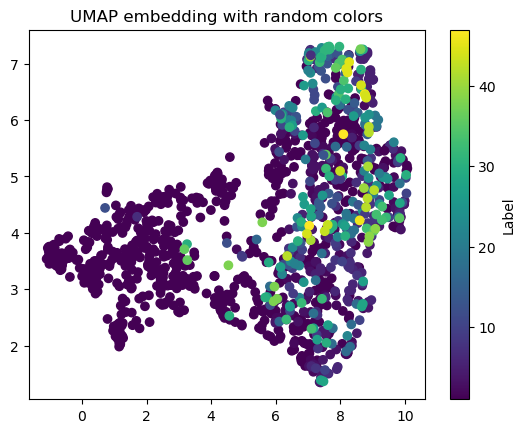

In [8]:
color=dF['Label']

#generalized PLOT UMAP RESULTS without hyper parameters

plt.scatter(u[:,0],u[:,1],c=color,cmap='viridis')
plt.colorbar(label='Label')
plt.title('UMAP embedding with random colors')
plt.show()


In [110]:
print(u)

[[ 7.35042    3.1096323]
 [ 7.1012893  2.614715 ]
 [ 8.419772   5.294896 ]
 ...
 [10.219469   5.257925 ]
 [ 9.246013   5.4246955]
 [ 9.226574   5.37308  ]]


### Here , we consider umap HyperParameters from previous examination as n_neighbours=50,min_dist=0.0,metric=euclidean

n_components=2, Trustworthiness=0.8982398965827577
n_components=3, Trustworthiness=0.9098864913224307
n_components=4, Trustworthiness=0.9150445061587045
n_components=5, Trustworthiness=0.9169846445098864
n_components=6, Trustworthiness=0.9183058903095594
n_components=7, Trustworthiness=0.917902805365768
n_components=8, Trustworthiness=0.9190176160781327
n_components=9, Trustworthiness=0.9184132216441317
n_components=10, Trustworthiness=0.9178033554688124


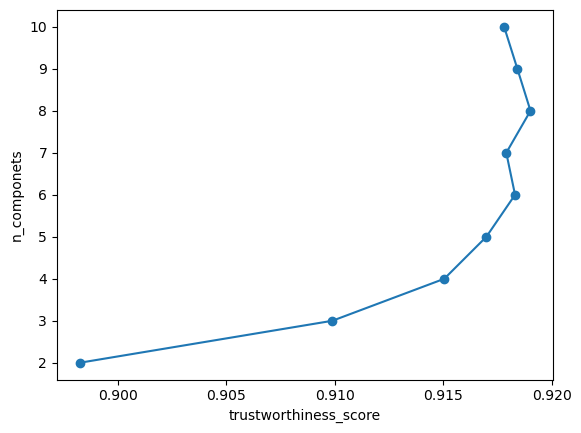

In [9]:
#calculate trustworthiness of UMAP components 

n_components_range = [2,3,4,5,6,7,8,9,10]
trustworthiness_scores = []
for n_components in n_components_range:
    umap_model = umap.UMAP(n_components=n_components,min_dist=0.0,n_neighbors=50,metric='euclidean',random_state=42)
    embeddings = umap_model.fit_transform(df_scaled)

    # Evaluate trustworthiness
    trustworthiness_score = trustworthiness(df_scaled, embeddings, n_neighbors=50)
    trustworthiness_scores.append(trustworthiness_score)

    print(f'n_components={n_components}, Trustworthiness={trustworthiness_score}')
#plot the relation
plt.plot(trustworthiness_scores,n_components_range,marker='o')
plt.xlabel("trustworthiness_score")
plt.ylabel("n_componets")
plt.show()

#### HDBSCAN clustering for 6 no.of UMAP components 

suitable min_samples and min_cluster for hdbscan w.r.t noise percentage

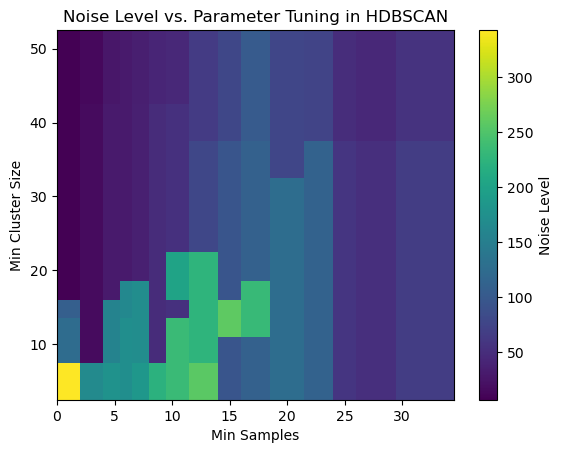

In [10]:
#noise-level
# UMAP with 6 components
umap_model = umap.UMAP(n_components=6,min_dist=0.0,n_neighbors=50,metric='euclidean',random_state=42)
umap_embeddings = umap_model.fit_transform(df_scaled)

# Varying parameters for HDBSCAN
min_cluster_sizes = [5, 10, 12, 15, 17, 20, 25, 30, 35, 40, 45, 50]
min_samples_values = [1, 3, 5, 6, 7, 9, 10, 13, 15, 17, 20, 23, 25, 27, 32]

# Initialize arrays to store noise levels
noise_levels = np.zeros((len(min_cluster_sizes), len(min_samples_values)))

# Loop through parameter combinations
for i, min_cluster_size in enumerate(min_cluster_sizes):
    for j, min_samples in enumerate(min_samples_values):
        hdbscan_clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, min_samples=min_samples)
        hdbscan_labels = hdbscan_clusterer.fit_predict(umap_embeddings)
        
        # Count the number of points labeled as noise (-1)
        noise_levels[i, j] = np.sum(hdbscan_labels == -1)

# Plot the noise levels
fig, ax = plt.subplots()
c = ax.pcolormesh(min_samples_values, min_cluster_sizes, noise_levels, cmap='viridis', shading='auto')
fig.colorbar(c, label='Noise Level')
ax.set_xlabel('Min Samples')
ax.set_ylabel('Min Cluster Size')
ax.set_title('Noise Level vs. Parameter Tuning in HDBSCAN')
plt.show()

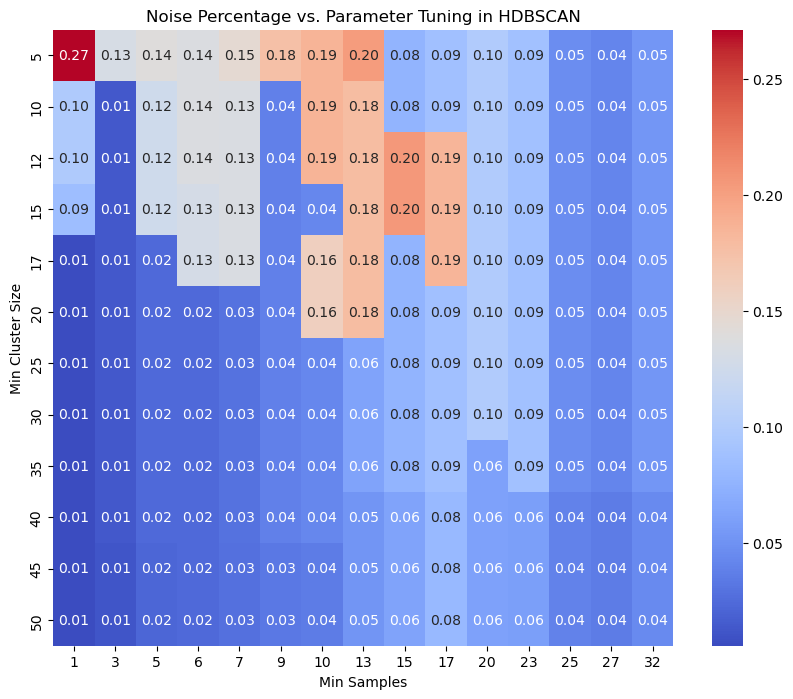

In [11]:
#noise percentage - through calculation

#DataFrame to store results
results = pd.DataFrame(columns=['min_cluster_size', 'min_samples', 'noise_percentage'])


# Parameter tuning
min_cluster_sizes = [5, 10, 12, 15, 17, 20, 25, 30, 35, 40, 45, 50]
min_samples_values = [1, 3, 5, 6, 7, 9, 10, 13, 15, 17, 20, 23, 25, 27, 32]

for min_cluster_size in min_cluster_sizes:
    for min_samples in min_samples_values:
        # HDBSCAN with parameter tuning
        hdbscan_clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, min_samples=min_samples)
        hdbscan_labels = hdbscan_clusterer.fit_predict(umap_embeddings)

        # Calculate noise level (percentage of points labeled as noise)
        noise_percentage = np.sum(hdbscan_labels == -1) / len(hdbscan_labels)

        # Append results to the DataFrame
        results = pd.concat([results, pd.DataFrame({'min_cluster_size': [min_cluster_size],
                                                     'min_samples': [min_samples],
                                                     'noise_percentage': [noise_percentage]})], ignore_index=True)

# Convert 'noise_percentage' to numeric
results['noise_percentage'] = pd.to_numeric(results['noise_percentage'])

# Reshape the DataFrame for the correlation matrix
corr_data = results.pivot_table(index='min_cluster_size', columns='min_samples', values='noise_percentage', aggfunc='mean')

# Plotting the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_data, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Noise Percentage vs. Parameter Tuning in HDBSCAN')
plt.xlabel('Min Samples')
plt.ylabel('Min Cluster Size')
plt.show()


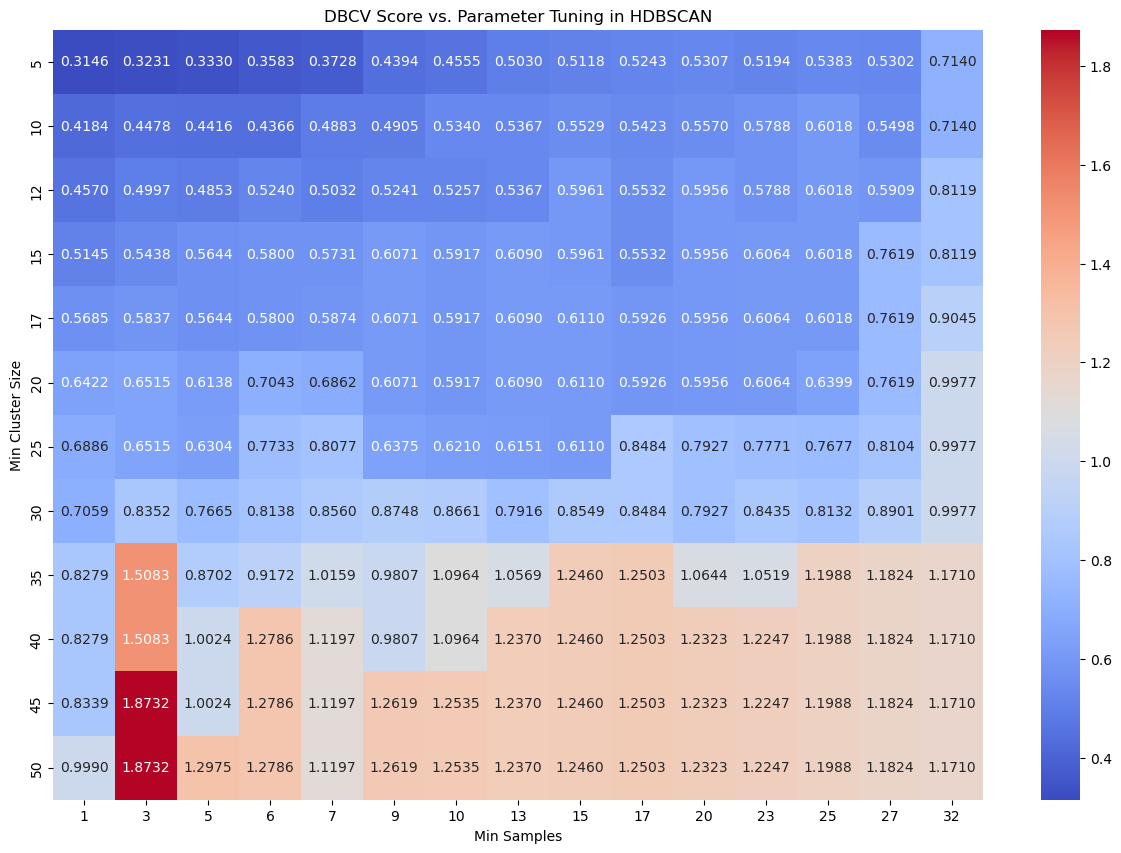

In [18]:
#dbcv score- heatmap
def calculate_dbcv(umap_embeddings, hdbscan_labels):
    distances = pairwise_distances(umap_embeddings, metric='euclidean')
    mean_intra_cluster_distances = []

    for cluster_label in np.unique(hdbscan_labels):
        cluster_indices = np.where(hdbscan_labels == cluster_label)[0]
        if len(cluster_indices) > 1:
            cluster_distances = distances[cluster_indices][:, cluster_indices]
            mean_intra_cluster_distances.append(np.mean(cluster_distances[np.triu_indices(len(cluster_distances), k=1)]))

    return np.mean(mean_intra_cluster_distances)

# DataFrame to store results
results = pd.DataFrame(columns=['min_cluster_size', 'min_samples', 'dbcv_score'])

# Parameter tuning
min_cluster_sizes = [5, 10, 12, 15, 17, 20, 25, 30, 35, 40, 45, 50]
min_samples_values = [1, 3, 5, 6, 7, 9, 10, 13, 15, 17, 20, 23, 25, 27, 32]

for min_cluster_size in min_cluster_sizes:
    for min_samples in min_samples_values:
        # HDBSCAN with parameter tuning
        hdbscan_clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, min_samples=min_samples)
        hdbscan_labels = hdbscan_clusterer.fit_predict(umap_embeddings)

        # Calculate DBCV Score
        dbcv_score = calculate_dbcv(umap_embeddings, hdbscan_labels)

        # Append results to the DataFrame
        results = pd.concat([results, pd.DataFrame({'min_cluster_size': [min_cluster_size],
                                                     'min_samples': [min_samples],
                                                     'dbcv_score': [dbcv_score]})], ignore_index=True)

# Reshape the DataFrame for the correlation matrix
corr_data = results.pivot_table(index='min_cluster_size', columns='min_samples', values='dbcv_score', aggfunc='mean')

# Plotting the correlation matrix
plt.figure(figsize=(15, 10))
sns.heatmap(corr_data, annot=True, cmap='coolwarm', fmt=".4f")
plt.title('DBCV Score vs. Parameter Tuning in HDBSCAN')
plt.xlabel('Min Samples')
plt.ylabel('Min Cluster Size')
plt.show()


### my DBCV code

float64


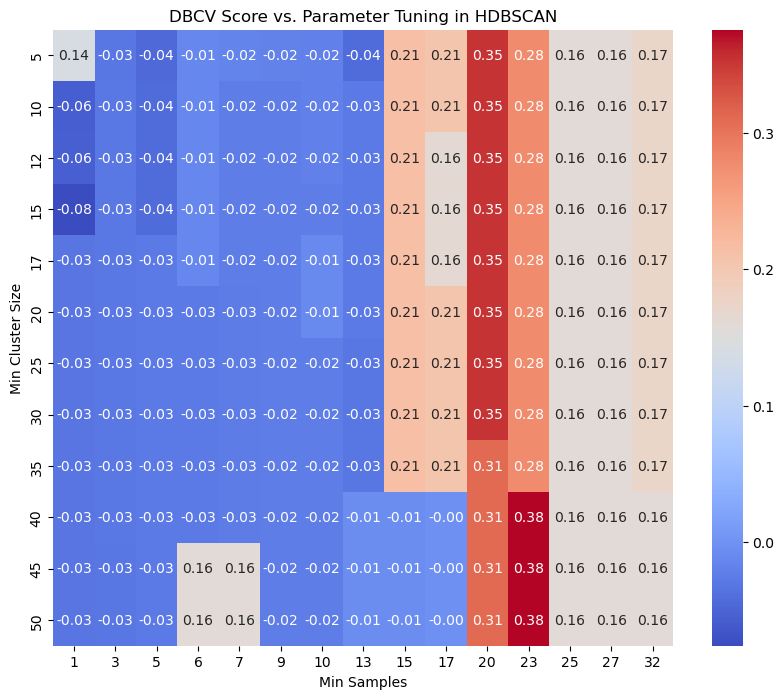

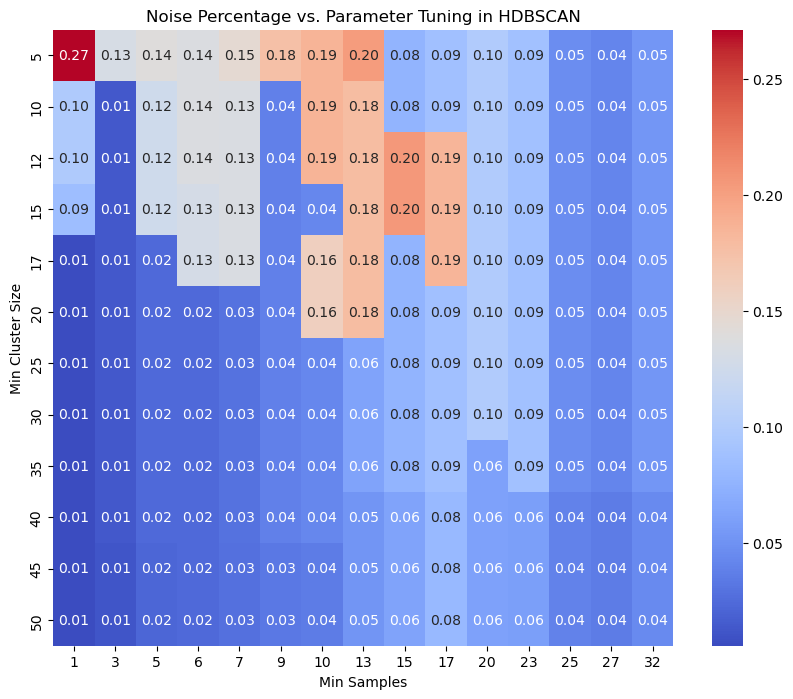

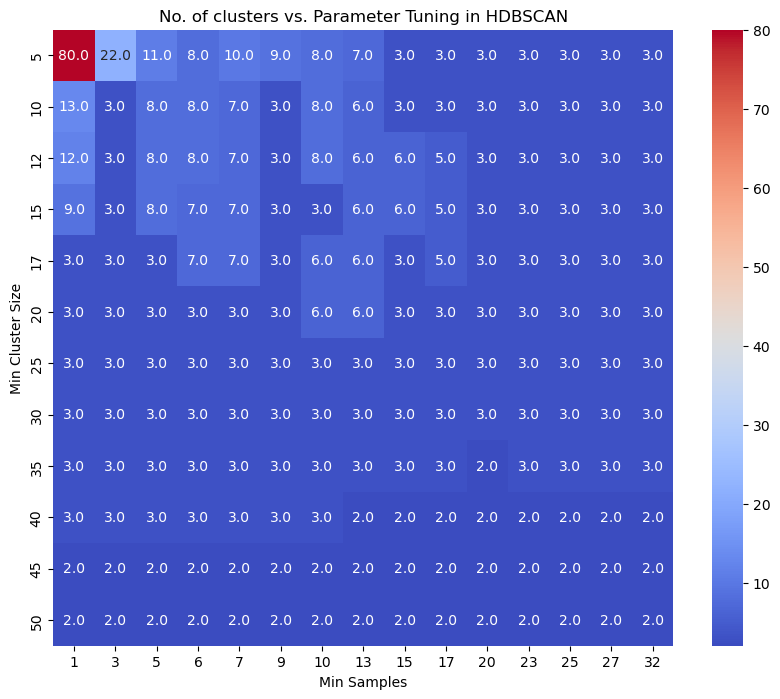

In [19]:
from hdbscan import validity
# DataFrame to store results
results = pd.DataFrame(columns=['min_cluster_size', 'min_samples', 'dbcv_score'])

# Parameter tuning
min_cluster_sizes = [5, 10, 12, 15, 17, 20, 25, 30, 35, 40, 45, 50]
min_samples_values = [1, 3, 5, 6, 7, 9, 10, 13, 15, 17, 20, 23, 25, 27, 32]

print(umap_embeddings.dtype)
umap_embeddings = umap_embeddings.astype(np.double)   # needed to calculate the DBCV score, otherwise giving error with float values

for min_cluster_size in min_cluster_sizes:
    for min_samples in min_samples_values:
        # HDBSCAN with parameter tuning
        hdbscan_clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, min_samples=min_samples)
        hdbscan_labels = hdbscan_clusterer.fit_predict(umap_embeddings)

        # Calculate DBCV Score
        #dbcv_score = hdbscan.validity.relative_validity(hdbscan_clusterer)
        dbcv_score = hdbscan.validity.validity_index(umap_embeddings, hdbscan_labels)
        
        # Calculate noise level (percentage of points labeled as noise)
        noise_percentage = np.sum(hdbscan_labels == -1) / len(hdbscan_labels)
        
        # Calculate no. of clusters
        n_clusters=len(np.unique(hdbscan_labels))-1
                
        # Append results to the DataFrame
        results = pd.concat([results, pd.DataFrame({'min_cluster_size': [min_cluster_size],
                                                     'min_samples': [min_samples],
                                                    'noise_percentage': [noise_percentage],
                                                    'n_clusters': [n_clusters],
                                                     'dbcv_score': [dbcv_score]})], ignore_index=True)

# Reshape the DataFrame for the correlation matrix
corr_data1 = results.pivot_table(index='min_cluster_size', columns='min_samples', values='dbcv_score', aggfunc='mean')
corr_data2 = results.pivot_table(index='min_cluster_size', columns='min_samples', values='noise_percentage', aggfunc='mean')
corr_data3 = results.pivot_table(index='min_cluster_size', columns='min_samples', values='n_clusters', aggfunc='mean')

# Plotting the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_data1, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('DBCV Score vs. Parameter Tuning in HDBSCAN')
plt.xlabel('Min Samples')
plt.ylabel('Min Cluster Size')
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_data2, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Noise Percentage vs. Parameter Tuning in HDBSCAN')
plt.xlabel('Min Samples')
plt.ylabel('Min Cluster Size')
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_data3, annot=True, cmap='coolwarm', fmt=".1f")
plt.title('No. of clusters vs. Parameter Tuning in HDBSCAN')
plt.xlabel('Min Samples')
plt.ylabel('Min Cluster Size')
plt.show()

In [10]:
# UMAP with 6 components
umap_model = umap.UMAP(n_components=6,min_dist=0.0,n_neighbors=50,metric='euclidean',random_state=42)
umap_embeddings = umap_model.fit_transform(df_scaled)

#dbcv according to randomsearch
hdb = hdbscan.HDBSCAN(gen_min_span_tree=True).fit(umap_embeddings)

param_dist = {
    'min_samples': [1, 3, 5, 6, 7, 9, 10, 13, 15, 17, 20, 23, 25, 27, 32],
    'min_cluster_size': [10, 12, 15, 17, 20, 25, 30, 35, 40, 45, 50],
    'cluster_selection_epsilon': [0.1, 0.2, 0.3, 0.4],
    'cluster_selection_method': ['eom', 'leaf'],
    'metric': ['euclidean', 'manhattan']
}

validity_scorer = make_scorer(hdbscan.validity.validity_index, greater_is_better=True)

n_iter_search = 100
random_search = RandomizedSearchCV(
    hdb, param_distributions=param_dist, n_iter=n_iter_search, scoring=validity_scorer, random_state=42
)

random_search.fit(umap_embeddings)



/project/dsi/apps/python/3.9/lib/python3.9/site-packages/sklearn/model_selection/_validation.py:776: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/project/dsi/apps/python/3.9/lib/python3.9/site-packages/sklearn/model_selection/_validation.py", line 765, in _score
    scores = scorer(estimator, X_test)
TypeError: __call__() missing 1 required positional argument: 'y_true'

  warnings.warn(
/project/dsi/apps/python/3.9/lib/python3.9/site-packages/sklearn/model_selection/_validation.py:776: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/project/dsi/apps/python/3.9/lib/python3.9/site-packages/sklearn/model_selection/_validation.py", line 765, in _score
    scores = scorer(estimator, X_test)
TypeError: __call__() missing 1 required positional argument: 'y_true'


/project/dsi/apps/python/3.9/lib/python3.9/site-packages/sklearn/model_selection/_validation.py:776: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/project/dsi/apps/python/3.9/lib/python3.9/site-packages/sklearn/model_selection/_validation.py", line 765, in _score
    scores = scorer(estimator, X_test)
TypeError: __call__() missing 1 required positional argument: 'y_true'

  warnings.warn(
/project/dsi/apps/python/3.9/lib/python3.9/site-packages/sklearn/model_selection/_validation.py:776: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/project/dsi/apps/python/3.9/lib/python3.9/site-packages/sklearn/model_selection/_validation.py", line 765, in _score
    scores = scorer(estimator, X_test)
TypeError: __call__() missing 1 required positional argument: 'y_true'


/project/dsi/apps/python/3.9/lib/python3.9/site-packages/sklearn/model_selection/_validation.py:776: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/project/dsi/apps/python/3.9/lib/python3.9/site-packages/sklearn/model_selection/_validation.py", line 765, in _score
    scores = scorer(estimator, X_test)
TypeError: __call__() missing 1 required positional argument: 'y_true'

  warnings.warn(
/project/dsi/apps/python/3.9/lib/python3.9/site-packages/sklearn/model_selection/_validation.py:776: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/project/dsi/apps/python/3.9/lib/python3.9/site-packages/sklearn/model_selection/_validation.py", line 765, in _score
    scores = scorer(estimator, X_test)
TypeError: __call__() missing 1 required positional argument: 'y_true'


/project/dsi/apps/python/3.9/lib/python3.9/site-packages/sklearn/model_selection/_validation.py:776: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/project/dsi/apps/python/3.9/lib/python3.9/site-packages/sklearn/model_selection/_validation.py", line 765, in _score
    scores = scorer(estimator, X_test)
TypeError: __call__() missing 1 required positional argument: 'y_true'

  warnings.warn(
/project/dsi/apps/python/3.9/lib/python3.9/site-packages/sklearn/model_selection/_validation.py:776: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/project/dsi/apps/python/3.9/lib/python3.9/site-packages/sklearn/model_selection/_validation.py", line 765, in _score
    scores = scorer(estimator, X_test)
TypeError: __call__() missing 1 required positional argument: 'y_true'


/project/dsi/apps/python/3.9/lib/python3.9/site-packages/sklearn/model_selection/_validation.py:776: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/project/dsi/apps/python/3.9/lib/python3.9/site-packages/sklearn/model_selection/_validation.py", line 765, in _score
    scores = scorer(estimator, X_test)
TypeError: __call__() missing 1 required positional argument: 'y_true'

  warnings.warn(
/project/dsi/apps/python/3.9/lib/python3.9/site-packages/sklearn/model_selection/_validation.py:776: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/project/dsi/apps/python/3.9/lib/python3.9/site-packages/sklearn/model_selection/_validation.py", line 765, in _score
    scores = scorer(estimator, X_test)
TypeError: __call__() missing 1 required positional argument: 'y_true'


...

/project/dsi/apps/python/3.9/lib/python3.9/site-packages/sklearn/model_selection/_validation.py:776: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/project/dsi/apps/python/3.9/lib/python3.9/site-packages/sklearn/model_selection/_validation.py", line 765, in _score
    scores = scorer(estimator, X_test)
TypeError: __call__() missing 1 required positional argument: 'y_true'

  warnings.warn(
/project/dsi/apps/python/3.9/lib/python3.9/site-packages/sklearn/model_selection/_validation.py:776: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/project/dsi/apps/python/3.9/lib/python3.9/site-packages/sklearn/model_selection/_validation.py", line 765, in _score
    scores = scorer(estimator, X_test)
TypeError: __call__() missing 1 required positional argument: 'y_true'


/project/dsi/apps/python/3.9/lib/python3.9/site-packages/sklearn/model_selection/_validation.py:776: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/project/dsi/apps/python/3.9/lib/python3.9/site-packages/sklearn/model_selection/_validation.py", line 765, in _score
    scores = scorer(estimator, X_test)
TypeError: __call__() missing 1 required positional argument: 'y_true'

  warnings.warn(
/project/dsi/apps/python/3.9/lib/python3.9/site-packages/sklearn/model_selection/_validation.py:776: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/project/dsi/apps/python/3.9/lib/python3.9/site-packages/sklearn/model_selection/_validation.py", line 765, in _score
    scores = scorer(estimator, X_test)
TypeError: __call__() missing 1 required positional argument: 'y_true'


/project/dsi/apps/python/3.9/lib/python3.9/site-packages/sklearn/model_selection/_validation.py:776: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/project/dsi/apps/python/3.9/lib/python3.9/site-packages/sklearn/model_selection/_validation.py", line 765, in _score
    scores = scorer(estimator, X_test)
TypeError: __call__() missing 1 required positional argument: 'y_true'

  warnings.warn(
/project/dsi/apps/python/3.9/lib/python3.9/site-packages/sklearn/model_selection/_validation.py:776: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/project/dsi/apps/python/3.9/lib/python3.9/site-packages/sklearn/model_selection/_validation.py", line 765, in _score
    scores = scorer(estimator, X_test)
TypeError: __call__() missing 1 required positional argument: 'y_true'


/project/dsi/apps/python/3.9/lib/python3.9/site-packages/sklearn/model_selection/_validation.py:776: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/project/dsi/apps/python/3.9/lib/python3.9/site-packages/sklearn/model_selection/_validation.py", line 765, in _score
    scores = scorer(estimator, X_test)
TypeError: __call__() missing 1 required positional argument: 'y_true'

  warnings.warn(
/project/dsi/apps/python/3.9/lib/python3.9/site-packages/sklearn/model_selection/_search.py:953: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan n

RandomizedSearchCV(estimator=HDBSCAN(gen_min_span_tree=True), n_iter=100,
                   param_distributions={'cluster_selection_epsilon': [0.1, 0.2,
                                                                      0.3,
                                                                      0.4],
                                        'cluster_selection_method': ['eom',
                                                                     'leaf'],
                                        'metric': ['euclidean', 'manhattan'],
                                        'min_cluster_size': [10, 12, 15, 17, 20,
                                                             25, 30, 35, 40, 45,
                                                             50],
                                        'min_samples': [1, 3, 5, 6, 7, 9, 10,
                                                        13, 15, 17, 20, 23, 25,
                                                        27, 32]},
                   random_state=42, scoring=make_scorer(validity_index))

In [11]:
print(f"Best Parameters {random_search.best_params_}")
print(f"DBCV score: {random_search.best_estimator_.relative_validity_}")

Best Parameters {'min_samples': 20, 'min_cluster_size': 12, 'metric': 'euclidean', 'cluster_selection_method': 'eom', 'cluster_selection_epsilon': 0.4}
DBCV score: 0.021430007736644476


In [24]:
family_label

array(['ZF C2H2-type', 'ZF C2H2-type', 'ZF C2H2-type', ...,
       'ZF C2H2-type', 'Paired/Homeobox/PAI/RED',
       'Paired/Homeobox/PAI/RED'], dtype=object)

UMAP components - HDBSCAN clustering with resulting HyperParameters

In [25]:
import plotly.express as px
#hdbscan for two umap components 
#cluster the data using hdbscan
labels = hdbscan.HDBSCAN(
    min_samples=23,
    min_cluster_size=40,
    #metric='euclidean',
    #cluster_selection_epsilon=0.4,
    #cluster_selection_method='eom'
).fit_predict(umap_embeddings)
#visualize the results
clustered = (labels >= 0)
''''
plt.scatter(umap_embeddings[~clustered, 0],
            umap_embeddings[~clustered, 1],
            color=(0.5, 0.5, 0.5),
            s=1,
            alpha=0.5)


plt.scatter(umap_embeddings[clustered, 0],
            umap_embeddings[clustered, 1],
            #c=labels[clustered],
            c= family_label[clustered],
            s=1,
            #cmap='Spectral'
           );
plt.colorbar(scatter, label='label')
'''
fig = px.scatter(x=umap_embeddings[clustered, 0], y=umap_embeddings[clustered, 1], 
                    color=family_label[clustered],
                   size_max=2)
fig.update_layout(coloraxis_colorbar=dict(title='Family'))
fig.show()

fig = px.scatter(x=umap_embeddings[clustered, 0], y=umap_embeddings[clustered, 1], 
                    color=labels[clustered],
                   size_max=2)
fig.update_layout(coloraxis_colorbar=dict(title='Cluster'))
fig.show()

print(np.unique(labels))
num_noise_points = np.sum(labels == -1)

print(f"Number of Noise Points: {num_noise_points}")

[-1  0  1]
Number of Noise Points: 75


In [15]:
import plotly.express as px
 
df2=df.drop('Normalized HP Score', axis=1)  # the total value of this is always highest

#DataFrame with features and HDBSCAN labels
df_hdbscan = pd.concat([df2, pd.Series(labels, name='HDBSCAN_Labels')], axis=1)
 
# Melt the DataFrame to have a column for features, values, and HDBSCAN labels
df_melted = pd.melt(df_hdbscan, id_vars=['HDBSCAN_Labels'], value_vars=df2.columns)
 
# Create a sunburst plot
fig = px.sunburst(df_melted, path=['HDBSCAN_Labels', 'variable'], values='value',
                  title='Sunburst Plot of Features by Cluster in HDBSCAN')
 
fig.show()

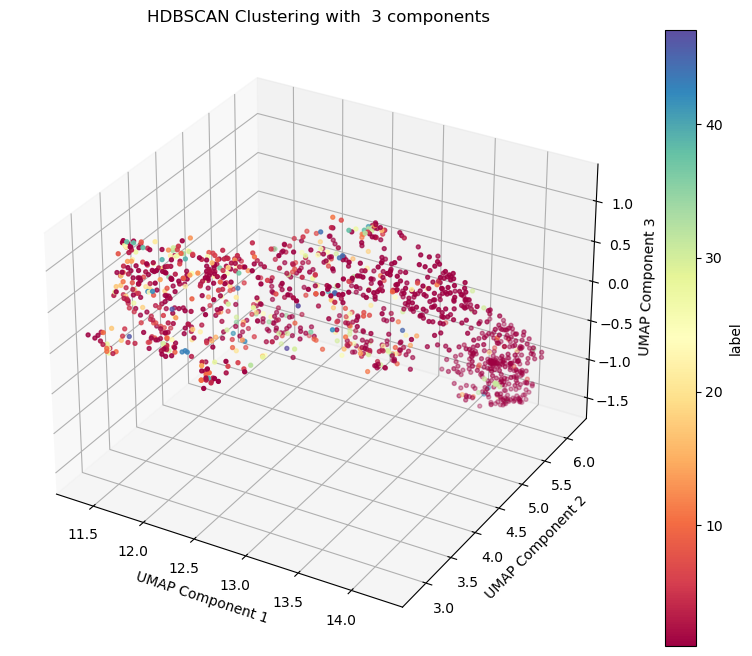

Number of Noise Points: 211


In [22]:
# Assuming DataFrame df obtained the UMAP embedding with 3 components
umap_model_3d = umap.UMAP(n_components=6,min_dist=0.0,n_neighbors=50,metric='euclidean',random_state=42)
umap_embedding_3d = umap_model_3d.fit_transform(df_scaled)

# HDBSCAN clustering with adjusted parameters
labels_3d = hdbscan.HDBSCAN(
    min_samples=3,
    min_cluster_size=50,
    #metric='euclidean',
    #cluster_selection_epsilon=0.4,
    #cluster_selection_method='eom'
).fit_predict(umap_embedding_3d)

# Visualize the results in 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot with thicker points
scatter=ax.scatter(umap_embedding_3d[:, 0], umap_embedding_3d[:, 1], umap_embedding_3d[:, 2], c=family_label, s=8, cmap='Spectral')
plt.colorbar(scatter, label='label')
ax.set_xlabel('UMAP Component 1')
ax.set_ylabel('UMAP Component 2')
ax.set_zlabel('UMAP Component 3')
ax.set_title('HDBSCAN Clustering with  3 components')

plt.show()

num_noise_points = np.sum(labels_3d == -1)
print(f"Number of Noise Points: {num_noise_points}")

# HDBSCAN COMPUTATIONS

In [122]:
#Adjustable rand score and mutual info 

features = df_scaled
true_labels = dF['Numbering']

def perform_umap_hdbscan(components, features):
    umap = UMAP(n_components=components,n_neighbors=50, min_dist=0.0,metric='euclidean',random_state=42)
    umap_result = umap.fit_transform(features)
    
    hdbscan_clusterer = hdbscan.HDBSCAN(min_samples=7,min_cluster_size=40,cluster_selection_epsilon=0.1,cluster_selection_method='eom')
    hdbscan_labels = hdbscan_clusterer.fit_predict(umap_result)
    
    return hdbscan_labels

components_list = [2, 3, 4, 5, 6, 7, 8, 9, 10]

for components in components_list:
    umap_hdbscan_labels = perform_umap_hdbscan(components, features)
    
    adjusted_rand = adjusted_rand_score(true_labels, umap_hdbscan_labels)
    adjusted_mutual_info = adjusted_mutual_info_score(true_labels, umap_hdbscan_labels)
    #noise percentage
    noise_percentage = np.sum(hdbscan_labels == -1) / len(hdbscan_labels)

    
    print(f"UMAP Components: {components}, Adjusted Rand Score: {adjusted_rand}, Adjusted Mutual Info Score: {adjusted_mutual_info}, Noise Percentage: {noise_percentage}")


/Users/pritheekakarla/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


UMAP Components: 2, Adjusted Rand Score: 0.0, Adjusted Mutual Info Score: -2.1565652099625785e-13, Noise Percentage: 0.008948545861297539


/Users/pritheekakarla/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


UMAP Components: 3, Adjusted Rand Score: 0.0, Adjusted Mutual Info Score: 2.3610554438280195e-13, Noise Percentage: 0.008948545861297539


/Users/pritheekakarla/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


...

UMAP Components: 8, Adjusted Rand Score: 0.0, Adjusted Mutual Info Score: -6.112515158964953e-14, Noise Percentage: 0.008948545861297539


/Users/pritheekakarla/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


UMAP Components: 9, Adjusted Rand Score: 0.0, Adjusted Mutual Info Score: -7.907953688789973e-14, Noise Percentage: 0.008948545861297539


/Users/pritheekakarla/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


UMAP Components: 10, Adjusted Rand Score: 0.0, Adjusted Mutual Info Score: 9.814221370626573e-14, Noise Percentage: 0.008948545861297539


check the noise points

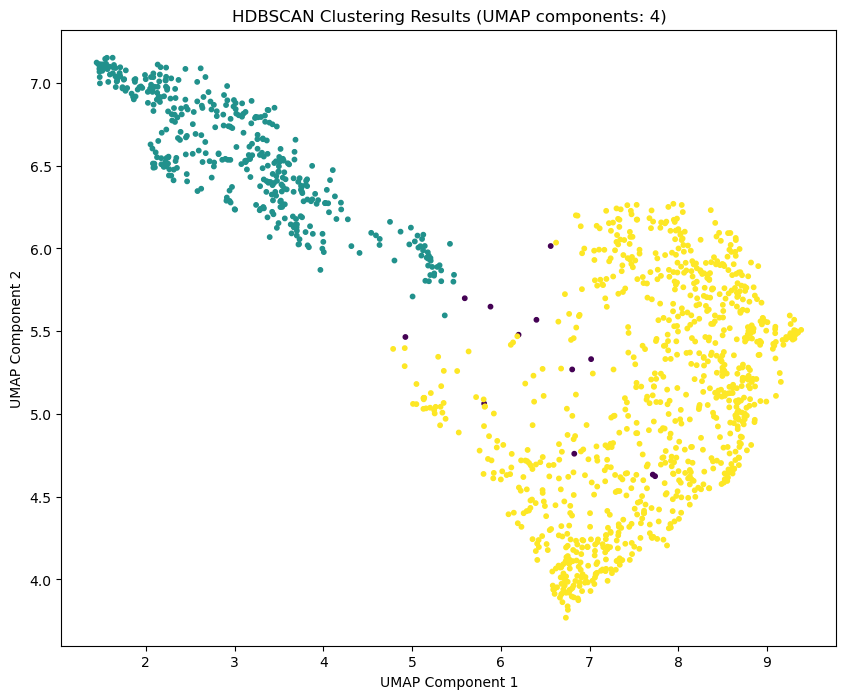

Number of Noise Points: 12


In [123]:
#noise pionts in 2d plot with 2 umap components
plt.figure(figsize=(10, 8))
plt.scatter(umap_embeddings[:, 0], umap_embeddings[:, 1], c=hdbscan_labels, cmap='viridis', s=10)
plt.title('HDBSCAN Clustering Results (UMAP components: 4)')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.show()

num_noise_points = np.sum(hdbscan_labels == -1)

print(f"Number of Noise Points: {num_noise_points}")

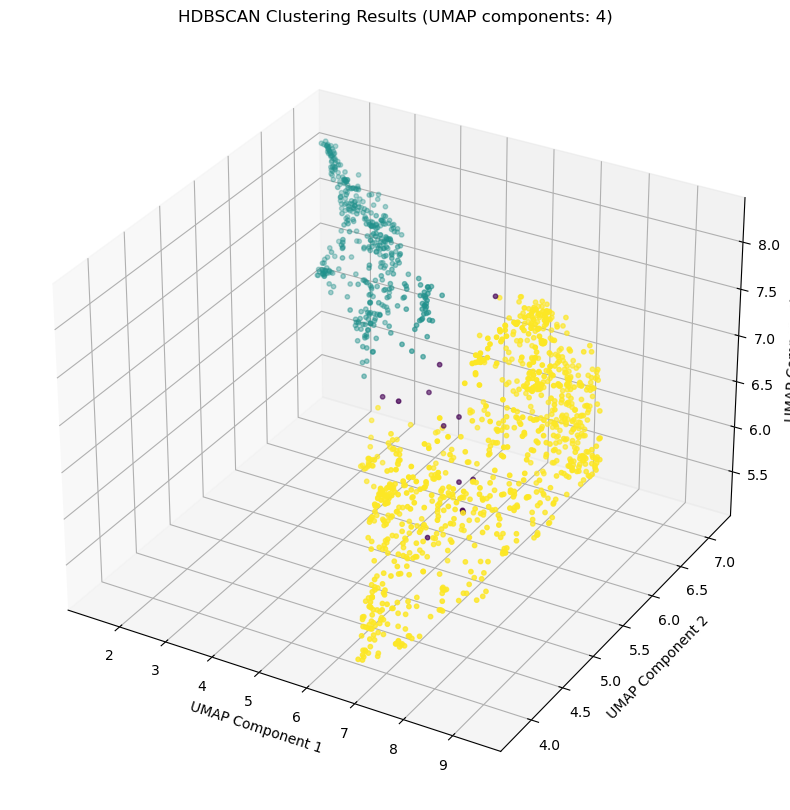

Number of Noise Points: 12


In [136]:
#3D plot with 3 UMAP-components
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot with UMAP components 
ax.scatter(umap_embeddings[:, 0], umap_embeddings[:, 1], umap_embeddings[:, 2], c=hdbscan_labels, cmap='viridis', s=10)


ax.set_xlabel('UMAP Component 1')
ax.set_ylabel('UMAP Component 2')
ax.set_zlabel('UMAP Component 3')


ax.set_title('HDBSCAN Clustering Results (UMAP components: 4)')

plt.show()

#print no.of noise points

num_noise_points = np.sum(hdbscan_labels == -1)

print(f"Number of Noise Points: {num_noise_points}")

# K-Means clustering using umap-4 components 

In [125]:
#visualize clustering
#visualize the clusters

#assume empty list to store intertia values
inertia=[]
for k in range(1,11):
   #test no.of clusters
   kmeans = KMeans(n_clusters = k, n_init='auto')

   #fit the model
   kmeans.fit(umap_embeddings)
    
    #append intertia for each k
   inertia.append(kmeans.inertia_)

#cluster's label and centroid
cluster_labels = kmeans.labels_
cluster_centers = kmeans.cluster_centers_

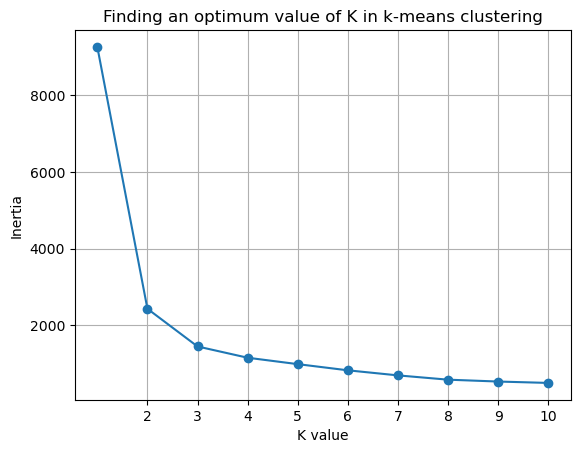

In [126]:
#plotting elbow curve
plt.plot(range(1,11),inertia,marker='o')
plt.xlabel("K value")
plt.ylabel("Inertia")
#plt.title("The Elbow Method using Inertia")
plt.title("Finding an optimum value of K in k-means clustering")
plt.xticks(range(2,k+1))
plt.grid(True)
plt.show()

7 clusters seems to be feasible - because at 7 , we can observe the d/df=0(differentiation)


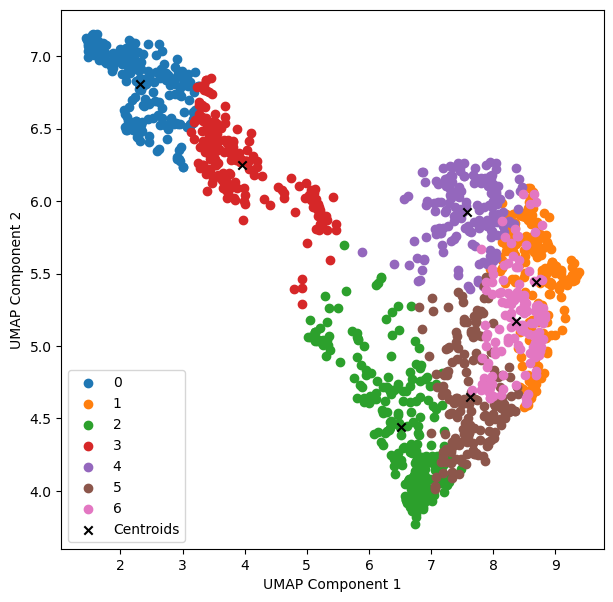

In [127]:
#visualize the 2d figure with 7 clusters

#kmeans model with 10 clusters
model = KMeans(n_clusters=7,init='k-means++',n_init='auto')

#labeling by colouring clusters
label=model.fit_predict(umap_embeddings)

#define centriods to clusters
centers = np.array(model.cluster_centers_)

#scatter plot with specific size
plt.figure(figsize = (7,7))

uniq = np.unique(label)

#for loop iterate through each each unique cluster label 

for i in uniq:

#plot data points corresponding to each cluster label 
 plt.scatter(umap_embeddings[label == i,0 ],umap_embeddings[label == i,1 ],label=i)
#plot centroids stored in centers with marking as 'x' in black
plt.scatter(centers[:,0],centers[:,1],marker='x',color='black',label = 'Centroids')
plt.xlabel("UMAP Component 1")
plt.ylabel("UMAP Component 2")
plt.legend()
plt.show()

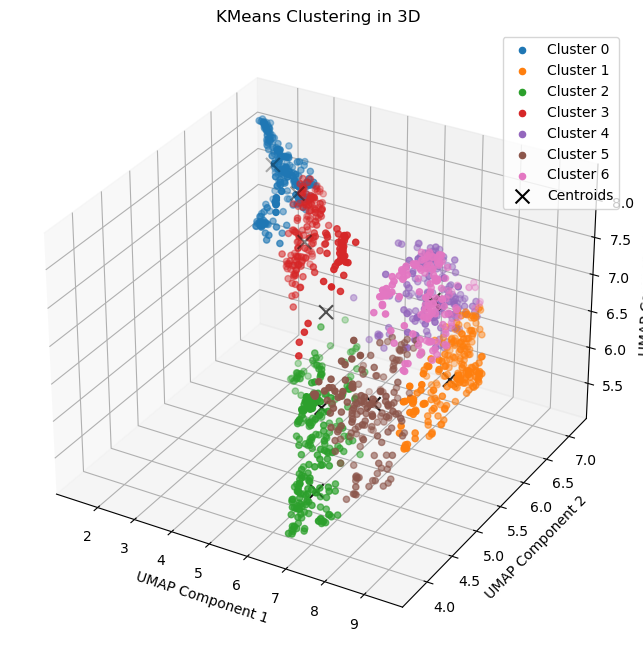

In [128]:
# Visualize in 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot for each cluster
for cluster in range(7):
    ax.scatter(umap_embeddings[label == cluster, 0],
               umap_embeddings[label == cluster, 1],
               umap_embeddings[label == cluster, 2],
               label=f'Cluster {cluster}',s=20)

# Plot centroids
ax.scatter(kmeans.cluster_centers_[:, 0],
           kmeans.cluster_centers_[:, 1],
           kmeans.cluster_centers_[:, 2],
           marker='x', color='black', s=100, label='Centroids')

ax.set_xlabel('UMAP Component 1')
ax.set_ylabel('UMAP Component 2')
ax.set_zlabel('UMAP Component 3')
ax.set_title('KMeans Clustering in 3D')
ax.legend()

plt.show()

Text(0.5, 1.0, 'Silhouette Score per No.of Clusters')

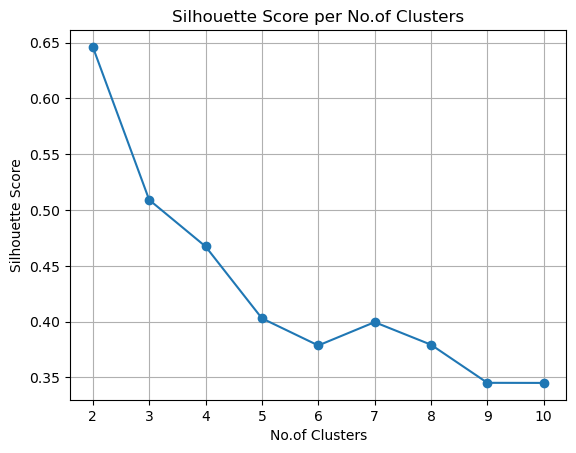

In [129]:
#silhouette score for kmeans-clustering - umap components 

silhouette_scores = []
for k in range (2,11):
    kmeans = KMeans(n_clusters = k , init = 'k-means++', random_state=42, n_init='auto')
    kmeans.fit(umap_embeddings)
    cluster_labels = kmeans.labels_
    silhouette_avg = silhouette_score(umap_embeddings,cluster_labels)
    silhouette_scores.append(silhouette_avg)
    
#visulaize silhouette scores through plotting
plt.plot(range(2,k+1),silhouette_scores,marker='o')
plt.xlabel("No.of Clusters")
plt.ylabel("Silhouette Score")
plt.xticks(range(2,k+1))
plt.grid(True)

plt.title("Silhouette Score per No.of Clusters")

In [130]:
df.head()

,Normalized HP Score,A fraction,C fraction,D fraction,E fraction,F fraction,G fraction,H fraction,I fraction,L fraction,...,N fraction,P fraction,Q fraction,S fraction,T fraction,V fraction,W fraction,Y fraction,f+,|f+ - f-|
0,0.418204,0.056287,0.029940,0.049102,0.085030,0.032335,0.081437,0.045509,0.027545,0.083832,...,0.028743,0.097006,0.032335,0.116168,0.043114,0.035928,0.004790,0.014371,0.113772,0.020359
1,0.433246,0.073826,0.030201,0.048098,0.073826,0.033557,0.108501,0.036913,0.024609,0.093960,...,0.027964,0.109620,0.034676,0.092841,0.038031,0.031320,0.003356,0.013423,0.104027,0.017897
2,0.434089,0.075071,0.045326,0.033994,0.073654,0.033994,0.038244,0.039660,0.033994,0.079320,...,0.048159,0.092068,0.035411,0.104816,0.048159,0.041076,0.001416,0.031161,0.117564,0.009915
3,0.447785,0.083507,0.039666,0.025052,0.048017,0.031315,0.087683,0.048017,0.025052,0.087683,...,0.018789,0.102296,0.039666,0.114823,0.052192,0.045929,0.002088,0.031315,0.110647,0.037578
4,0.391120,0.056396,0.037139,0.055021,0.107290,0.023384,0.053645,0.045392,0.030261,0.048143,...,0.033012,0.068776,0.055021,0.046768,0.064649,0.066025,0.001376,0.024759,0.151307,0.011004
